In [1]:
!pip install pandas transformers torch matplotlib wordcloud nltk plotly

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from transformers import pipeline

In [5]:
import pandas as pd
import random

templates = [
"The proposed amendment will improve transparency in corporate governance.",
"This regulation may increase compliance burden for small businesses.",
"The policy change appears beneficial for investor protection.",
"The draft legislation requires more clarity regarding reporting requirements.",
"This amendment could lead to unnecessary administrative work for startups.",
"The proposal supports stronger financial accountability among corporations.",
"Small firms might struggle to meet the new regulatory standards.",
"The amendment encourages ethical business practices and transparency.",
"The regulation seems too complex for smaller companies to follow.",
"The policy provides better safeguards for minority shareholders.",
"The draft amendment may improve disclosure requirements for listed companies.",
"The proposal could increase operational costs for small enterprises.",
"The amendment aims to strengthen regulatory oversight.",
"The legislation might create additional reporting obligations.",
"The regulation will likely enhance market transparency.",
"The draft policy lacks clear implementation guidelines.",
"The amendment may help improve corporate accountability.",
"The proposal might discourage startups due to stricter compliance.",
"The legislation supports better financial governance.",
"The regulation could simplify certain reporting procedures.",
"The amendment may increase documentation requirements.",
"The proposal benefits long-term investors.",
"The draft legislation introduces stricter compliance measures.",
"The policy may improve monitoring of corporate activities.",
"The amendment might require companies to adopt better governance frameworks.",
"The regulation appears favorable for improving transparency.",
"The proposal could result in additional regulatory scrutiny.",
"The legislation may improve the quality of financial disclosures.",
"The amendment might increase administrative workload.",
"The regulation supports stronger enforcement mechanisms.",
"The proposal encourages responsible corporate behavior.",
"The draft policy might require better documentation from companies.",
"The amendment may enhance investor trust.",
"The legislation may create challenges for newly established businesses.",
"The regulation strengthens accountability mechanisms.",
"The proposal may introduce stricter compliance checks.",
"The amendment encourages improved reporting standards.",
"The legislation could lead to better corporate oversight.",
"The policy may benefit stakeholders through greater transparency.",
"The amendment might impose additional procedural requirements."
]

comments = [random.choice(templates) for _ in range(300)]

df = pd.DataFrame({"comment": comments})

df.to_csv("data_comments.csv", index=False)

df

,comment
0,The legislation supports better financial gove...
1,The draft policy lacks clear implementation gu...
2,The amendment encourages improved reporting st...
3,The regulation supports stronger enforcement m...
4,The legislation supports better financial gove...
...,...
295,The draft policy might require better document...
296,The amendment might impose additional procedur...
297,The amendment encourages improved reporting st...
298,The draft legislation requires more clarity re...


In [6]:
df = pd.read_csv("data_comments.csv")
df.head()

,comment
0,The legislation supports better financial gove...
1,The draft policy lacks clear implementation gu...
2,The amendment encourages improved reporting st...
3,The regulation supports stronger enforcement m...
4,The legislation supports better financial gove...


In [7]:
df.shape

(300, 1)

# SENTIMENT ANALYSIS

In [18]:
from transformers import pipeline

sentiment_pipeline = pipeline("sentiment-analysis")

No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f (https://huggingface.co/distilbert/distilbert-base-uncased-finetuned-sst-2-english).
Using a pipeline without specifying a model name and revision in production is not recommended.
Device set to use cpu


In [35]:
df["sentiment"] = df["comment"].apply(lambda x: sentiment_pipeline(x)[0]["label"])
df[["comment", "sentiment"]].head()

,comment,sentiment
0,The legislation supports better financial gove...,POSITIVE
1,The draft policy lacks clear implementation gu...,NEGATIVE
2,The amendment encourages improved reporting st...,POSITIVE
3,The regulation supports stronger enforcement m...,POSITIVE
4,The legislation supports better financial gove...,POSITIVE


# Generate Summary of Comments

In [42]:
def generate_summary(text):
    # If comment is short, return as is
    if len(text.split()) < 12:
        return text
    try:
        # Summarize only longer comments
        summary = summarizer(text, max_length=30, min_length=10, do_sample=False)
        return summary[0]['summary_text']
    except:
        return text

df["summary"] = df["comment"].apply(generate_summary)

df.head()

,comment,summary,sentiment
0,The legislation supports better financial gove...,The legislation supports better financial gove...,POSITIVE
1,The draft policy lacks clear implementation gu...,The draft policy lacks clear implementation gu...,NEGATIVE
2,The amendment encourages improved reporting st...,The amendment encourages improved reporting st...,POSITIVE
3,The regulation supports stronger enforcement m...,The regulation supports stronger enforcement m...,POSITIVE
4,The legislation supports better financial gove...,The legislation supports better financial gove...,POSITIVE


# Word Cloud Visualization

In [13]:
all_comments = " ".join(df["comment"])

In [14]:
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_comments)

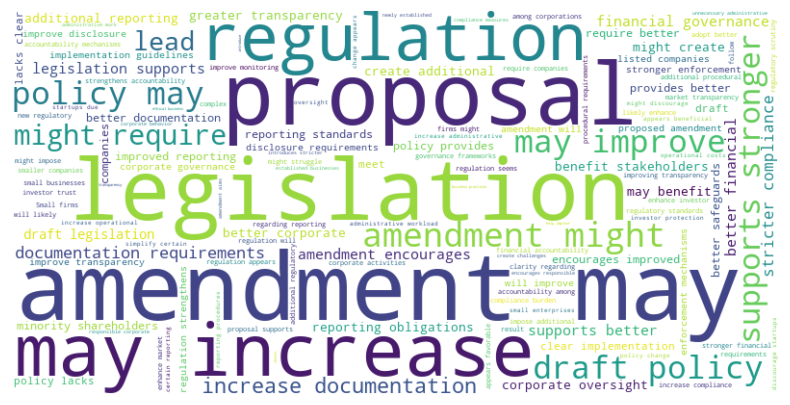

In [15]:
plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

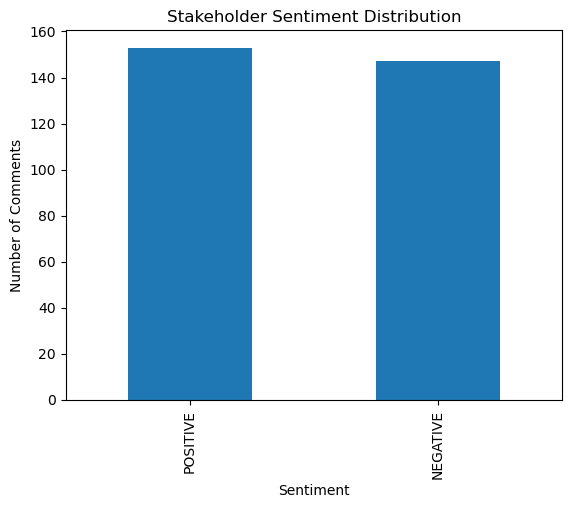

In [27]:
import matplotlib.pyplot as plt

df["sentiment"].value_counts().plot(kind="bar")
plt.title("Stakeholder Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Comments")
plt.show()

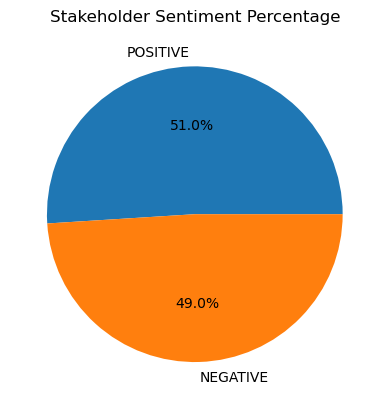

In [36]:
sentiment_counts = df["sentiment"].value_counts()

sentiment_counts.plot(kind="pie", autopct='%1.1f%%')

plt.title("Stakeholder Sentiment Percentage")
plt.ylabel("")
plt.show()

In [38]:
df.to_csv("legisai_analysis_output.csv", index=False)

In [39]:
new_comment = "The proposed compliance rules will improve corporate transparency."

sentiment = sentiment_pipeline(new_comment)[0]["label"]

summary = generate_summary(new_comment)

print("Comment:", new_comment)
print("Sentiment:", sentiment)
print("Summary:", summary)

Your max_length is set to 20, but your input_length is only 11. Since this is a summarization task, where outputs shorter than the input are typically wanted, you might consider decreasing max_length manually, e.g. summarizer('...', max_length=5)


Comment: The proposed compliance rules will improve corporate transparency.
Sentiment: POSITIVE
Summary:  The proposed compliance rules will improve corporate transparency .


In [43]:
new_comment = """The proposed amendment to corporate compliance rules is a positive step. 
However, small businesses may face difficulty implementing these requirements due to 
increased reporting obligations and compliance costs."""

sentiment = sentiment_pipeline(new_comment)[0]["label"]

summary = generate_summary(new_comment)

print("Comment:", new_comment)
print("Sentiment:", sentiment)
print("Summary:", summary)

Comment: The proposed amendment to corporate compliance rules is a positive step. 
However, small businesses may face difficulty implementing these requirements due to 
increased reporting obligations and compliance costs.
Sentiment: NEGATIVE
Summary:  Small businesses may face difficulty implementing these requirements due to  increased reporting obligations and compliance costs . The proposed amendment to corporate compliance rules is a
